# EDA (Exploratory Data Analysis)

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_all
from src.config import FIGURES

sns.set_theme(style="whitegrid")

FIGURES.mkdir(parents=True, exist_ok=True)

# View Dataframe

In [2]:
df = load_all()
print(f"Total data: {df.shape[0]} tweets")
print(f"Kolom: {list(df.columns)}")
df.head(10)

Total data: 1919 tweets
Kolom: ['provider', 'tweet_part1', 'tweet_part2', 'tweet_raw']


,provider,tweet_part1,tweet_part2,tweet_raw
0,indosat,gangguan kah?,Ini,gangguan kah? Ini
1,indosat,knp tiba2 gabisa buat internetan sih,ini sinyal,knp tiba2 gabisa buat internetan sih ini sinyal
2,indosat,gimana ni,Gimana untuk jadwal teknisi nya\nIni sudah seh...,gimana ni Gimana untuk jadwal teknisi nya\nIni...
3,indosat,NaN,IM3 kenapa sinyalnya ilang timbul,IM3 kenapa sinyalnya ilang timbul
4,indosat,NaN,gangguan kah ?,gangguan kah ?
5,indosat,NaN,halo ini kenapa kartu m3 saya tiba tiba mati y...,halo ini kenapa kartu m3 saya tiba tiba mati ...
6,indosat,NaN,lagi kenapa sih? ga bisa dipake buat internetan,lagi kenapa sih? ga bisa dipake buat internetan
7,indosat,NaN,kak wifinya merah kak ini complain kemana ya?,kak wifinya merah kak ini complain kemana ya?
8,indosat,NaN,plis knpsih gabisa internetan,plis knpsih gabisa internetan
9,indosat,NaN,WTB kuota,WTB kuota


## Informasi Dataset per Provider

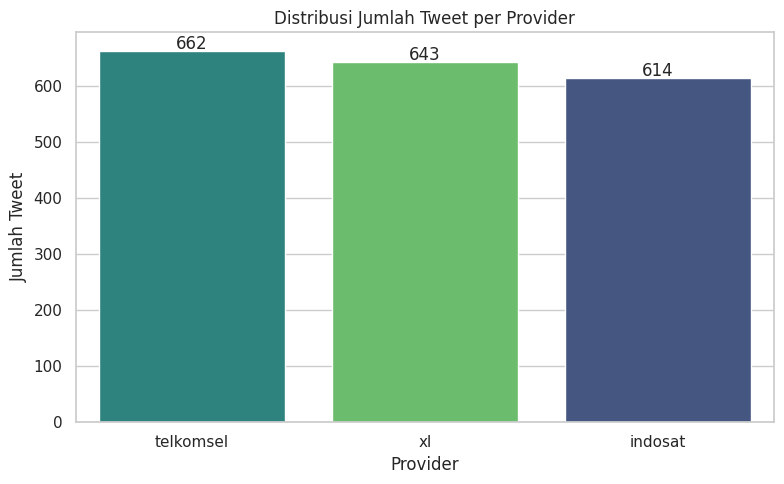

Tabel Distribusi Provider:


,Count,Percentage (%)
provider,,
telkomsel,662,34.497134
xl,643,33.507035
indosat,614,31.995831


In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='provider',
    hue='provider',
    palette='viridis',
    order=df['provider'].value_counts().index,
    legend=False
)
plt.title('Distribusi Jumlah Tweet per Provider')
plt.xlabel('Provider')
plt.ylabel('Jumlah Tweet')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig(FIGURES / "01_distribusi_provider.png")
plt.show()

print("Tabel Distribusi Provider:")
counts = df['provider'].value_counts()
percentages = df['provider'].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
display(dist_df)

## Analisis Panjang Tweet

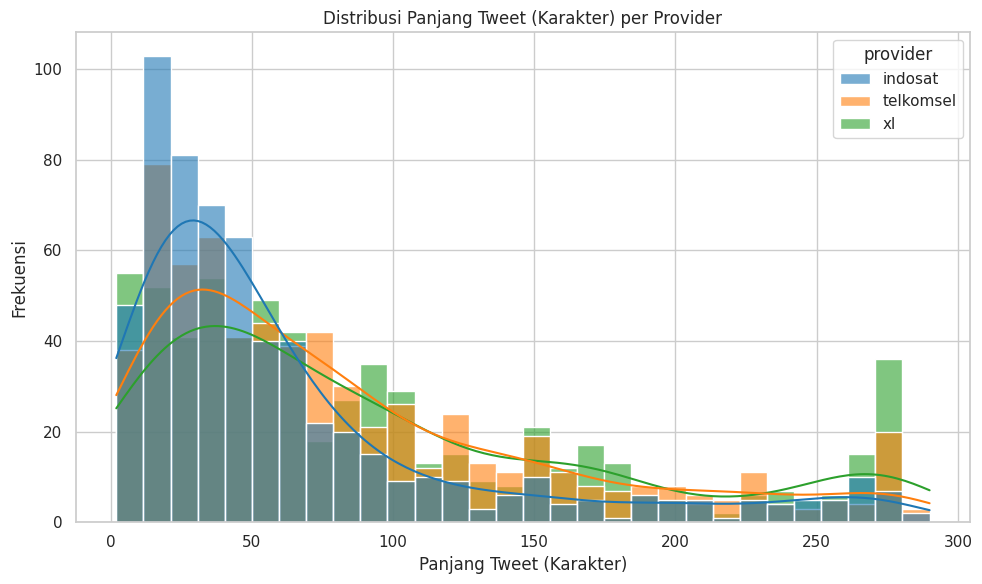

Statistik Deskriptif Panjang Tweet per Provider:


,mean,median,min,max
provider,,,,
indosat,64.47,41.0,4,290
telkomsel,83.66,61.5,3,281
xl,93.82,67.0,2,280


In [4]:
df['tweet_length'] = df['tweet_raw'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tweet_length', hue='provider', bins=30, kde=True, palette='tab10', alpha=0.6)
plt.title('Distribusi Panjang Tweet (Karakter) per Provider')
plt.xlabel('Panjang Tweet (Karakter)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.savefig(FIGURES / "01_distribusi_panjang_tweet.png")
plt.show()

print("Statistik Deskriptif Panjang Tweet per Provider:")
display(df.groupby('provider')['tweet_length'].agg(['mean', 'median', 'min', 'max']).round(2))

## Analisis Missing Values

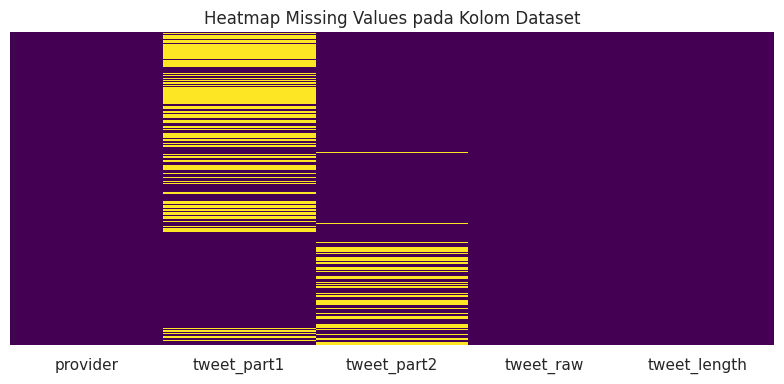

Jumlah Missing Values per Kolom:


provider          0
tweet_part1     689
tweet_part2     293
tweet_raw         0
tweet_length      0
dtype: int64

In [5]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Heatmap Missing Values pada Kolom Dataset')
plt.tight_layout()
plt.savefig(FIGURES / "01_missing_values.png")
plt.show()

print("Jumlah Missing Values per Kolom:")
display(df.isnull().sum())

## Sample Tweet Inspection per Provider

In [6]:
with pd.option_context('display.max_colwidth', None):
    for provider in df['provider'].unique():
        print(f"\n{'='*50}")
        print(f"[{provider.upper()}] - 5 Sample Tweets")
        print(f"{'='*50}")
        sample_tweets = df[df['provider'] == provider]['tweet_raw'].head(5)
        for i, tweet in enumerate(sample_tweets, 1):
            print(f"{i}. {tweet}\n")


[INDOSAT] - 5 Sample Tweets
1. gangguan kah? Ini

2. knp tiba2 gabisa buat internetan sih ini sinyal

3. gimana ni Gimana untuk jadwal teknisi nya
Ini sudah seharian loh dari pagi nggak ada koneksi dengan modem tetap menyala
Kalau tidak bisa tolong kembalikan saja uang saya yg kemarin saya bayar WiFi nya
Saya mau pindah provider lain nya
After sales

4.  IM3 kenapa sinyalnya ilang timbul

5.  gangguan kah ?


[TELKOMSEL] - 5 Sample Tweets
1.  ngapa deh

2. ente setan paketan makin mahal tapi

3. itu, udah mahal, Gila apa ya dari kemarin ga ada

4.  lagi gangguan kah? gue dari siang gak stabil banget

5.  kenapasi gaada


[XL] - 5 Sample Tweets
1. lagi eror? Kok sinyalku ilang-ilangan, udah restart tetep aja gitu 

2. telkom e mkin menurun prah hampir e
m3 mid
smf sama aja ky telkom

3. Sekarang aku ga takut lagi buat scroll sosmed kapan aja karena pake ULTRA 5G+ di Kabupaten Gresik secepat itu, speed testnya di atas 300 Mbps. Yuk download aplikasi myXL dan aktifin

4. Speed test aku d